In [1]:
# !pip install fusion_solar_py -q

In [2]:
# from kaggle_secrets import UserSecretsClient

# user_secrets = UserSecretsClient()
# FUSION_SOLAR_CLIENT_PASSWORD = user_secrets.get_secret("FUSION_SOLAR_CLIENT_PASSWORD")
# FUSION_SOLAR_CLIENT_USERNAME = user_secrets.get_secret("FUSION_SOLAR_CLIENT_USERNAME")
# LAT = float(user_secrets.get_secret("LAT"))
# LON = float(user_secrets.get_secret("LON"))

In [3]:
import os

from dotenv import load_dotenv

load_dotenv()
FUSION_SOLAR_CLIENT_PASSWORD = os.environ.get("FUSION_SOLAR_CLIENT_PASSWORD")
FUSION_SOLAR_CLIENT_USERNAME = os.environ.get("FUSION_SOLAR_CLIENT_USERNAME")
LAT = float(os.environ.get("LAT"))
LON = float(os.environ.get("LON"))

In [4]:
from time import sleep
from datetime import timedelta, datetime

import numpy as np
import pandas as pd
import pytz

from energymanagementrl.fusion_solar_extension import FusionSolarClientParsed, PeriodicTask, \
    FusionSolarExceptionExtended
from energymanagementrl.pv_prod_simulation.main import run_energy_production_prediction, WeatherType
from energymanagementrl.pv_prod_simulation.simulation import PanelModel, ArrayConfig, PlantConfig
from energymanagementrl.simulation import sparse_matrix
from energymanagementrl.rl.utils import extract_values_gen
from stable_baselines3 import DQN

In [24]:
_model = DQN.load(
    # '../logs/best_model/best_model.zip',
    '../logs/ppo_inverter.0.1.b',
    # '../logs/ppo_inverter.b.9.0',
)

In [6]:
panel_model = PanelModel(pdc0=0.42, temp_model_a=-3.56, temp_model_b=-0.075, delta_t=3, gamma_pdc=-0.004)
num_panels = 14
arrays = [ArrayConfig(name='sud_east', panel_model=panel_model, num_panels=num_panels, tilt_angle=25, azimuth=110),
          ArrayConfig(name='nord_west', panel_model=panel_model, num_panels=num_panels, tilt_angle=18, azimuth=290)]

_plant_config = PlantConfig(
    latitude=LAT, longitude=LON, timezone='Europe/Rome', inverter_pdc0=6, arrays=arrays
)

In [7]:
_client = FusionSolarClientParsed(FUSION_SOLAR_CLIENT_USERNAME, FUSION_SOLAR_CLIENT_PASSWORD,
                                  huawei_subdomain="uni004eu5")
periodic_task = PeriodicTask(_client.keep_alive, interval=5)
periodic_task.start()
_plant_id = _client.get_plant_ids()[0]
battery_id = _client.get_battery_ids(_plant_id)[0]

Periodic task started.


In [34]:
def get_flow_and_energy(client, plant_id):
    prod_kw, load_kw, store_kw, grid_kw, soc = client.get_plant_flow_parsed(plant_id)
    prod_wh, load_wh, store_wh, grid_wh = [i * 1000 // 12 for i in (prod_kw, -load_kw, store_kw, grid_kw)]
    return prod_wh, load_wh, store_wh, grid_wh, soc


def get_history(client, plant_id, load_wh):
    now = datetime.now()
    history = pd.concat([
        client.get_plant_stats_parsed(
            plant_id,
            query_time=client._get_day_start_sec() + i * client.MILLISECONDS_IN_A_DAY,
            time_zone=2,
            time_zone_str='Europe/Rome'
        )
        for i in [-2, -1, 0]
    ]).usePower
    history = history[history.index <= now][-288 * 2:].replace('--', np.nan)
    history = history.astype('float') * 1000 // 12
    if np.isnan(history.iloc[-1]):
        history.iloc[-1] = load_wh
    if history.isnull().values.any():
        history.fillna(history.mean(), inplace=True)
    return history.resample('4h').mean()[1:]


def get_production_forecast(plant_config, start, end, weather_type=None):
    forecast_df = run_energy_production_prediction(
        plant_config,
        start.strftime('%Y-%m-%d %H:%M'),
        end.strftime('%Y-%m-%d %H:%M'),
        weather_type
    )
    return forecast_df.resample('5min').interpolate(method='linear').tz_localize(None)


def compute_production_residual(clear_sky_df, weather_dependent_df, forecast_range):
    weather_dependent_df = weather_dependent_df.loc[clear_sky_df.index]
    residual = abs(clear_sky_df.inverter_ac - weather_dependent_df.inverter_ac)
    production_power_kw_weather_dependent, residual = (
        np.array(column.iloc[forecast_range]) @ sparse_matrix
        for column in (weather_dependent_df.inverter_ac, residual)
    )

    return production_power_kw_weather_dependent * 1000 // 12, residual * 1000 // 12


def build_system_state(prod_wh, load_wh, store_wh, soc, grid_wh, history, weather_dependent, residual):
    state = {
        'prod_sim': {},
        'cons_sim': {},
        'batt_sim': {},
        'grid_sim': {},
    }

    for i, value in enumerate(weather_dependent):
        state['prod_sim'][f"energy_sample_{i}"] = value
    state["prod_sim"]["energy"] = prod_wh
    for i, value in enumerate(residual):
        state['prod_sim'][f"residual_sample_{i}"] = value

    for i, value in enumerate(history):
        state['cons_sim'][f"energy_sample_{i}"] = value
    state["cons_sim"]["energy"] = load_wh

    state["batt_sim"]["stored"] = (soc - 10) * 100
    state["batt_sim"]["charge_rate"] = -store_wh if store_wh < 0 else 0
    state["batt_sim"]["discharge_rate"] = store_wh if store_wh > 0 else 0

    state["grid_sim"]["feed_to_grid"] = -grid_wh if grid_wh < 0 else 0
    state["grid_sim"]["taken_from_grid"] = grid_wh if grid_wh > 0 else 0

    return state


def get_system_state(client, plant_id, plant_config):
    prod_wh, load_wh, store_wh, grid_wh, soc = get_flow_and_energy(client, plant_id)
    history = get_history(client, plant_id, load_wh)

    now = datetime.now()
    now_gmt = pytz.timezone('Europe/Rome').localize(now).astimezone(pytz.utc)

    clear_sky_start = now_gmt.replace(minute=now.minute // 5 * 5)
    clear_sky_end = clear_sky_start + timedelta(days=2)
    clear_sky_production_df = get_production_forecast(plant_config, clear_sky_start, clear_sky_end,
                                                      WeatherType.clear_sky)
    clear_sky_production_df = clear_sky_production_df.tz_localize('UTC').tz_convert('Europe/Rome').tz_localize(None)
    weather_start = now.replace(minute=now.minute // 5 * 5)
    weather_end = weather_start + timedelta(days=2)
    open_meteo_production_df = get_production_forecast(
        plant_config, weather_start, weather_end, WeatherType.open_meteo_forecast
    )

    forecast_range = [i * 12 for i in range(48)]

    production_power_kw_weather_dependent, residual = compute_production_residual(
        clear_sky_production_df, open_meteo_production_df, forecast_range
    )

    return build_system_state(
        prod_wh, load_wh, store_wh, soc, grid_wh, history,
        production_power_kw_weather_dependent, residual
    )

In [9]:
states_series = []

In [ ]:
def execute_control(client, plant_id, plant_config, model, active=False):
    """Executes control logic to adjust battery working mode based on model predictions."""
    action = 1
    state = {}

    try:
        # Retrieve system state
        state = get_system_state(client, plant_id, plant_config)
        obs = np.array(list(extract_values_gen(state))) / 1000

        # Validate observation length
        if len(obs) != 55:
            raise FusionSolarExceptionExtended(
                "Invalid observation length",
                FusionSolarExceptionExtended.ErrorCode.PARSING
            )

        # Predict action using the model
        action, _ = model.predict(obs)

        # Determine battery mode based on action
        battery_mode = (
            FusionSolarClientParsed.BatteryWorkingMode.MAXIMUM_SELF_CONSUMPTION
            if action == 1 else
            FusionSolarClientParsed.BatteryWorkingMode.FULLY_FEED_TO_GRID
        )

        # Set battery mode if active
        if active:
            client.set_battery_working_mode(battery_id, battery_mode)

        print(f"Battery Mode: {battery_mode.name}")

    except FusionSolarExceptionExtended as e:
        print(f"Error: {e.code}")

    return state, action


def main_loop():
    """Main loop for executing control at regular intervals."""
    try:
        while True:
            # Execute control logic
            state_, action_ = execute_control(
                client=_client,
                plant_id=_plant_id,
                plant_config=_plant_config,
                model=_model,
                active=True
            )

            # Log the state and action with a timestamp
            now = datetime.now()
            state_.update({
                'timestamp': now.timestamp(),
                'action': int(action_)
            })
            states_series.append(state_)

            # Calculate the next execution time (aligned to the next 5-minute interval)
            next_time = (now + timedelta(minutes=5 - now.minute % 5)).replace(second=0, microsecond=0)
            sleep_duration = (next_time - now).total_seconds()

            # Sleep until the next interval
            sleep(sleep_duration)

    finally:
        # Reset battery working mode on exit
        _client.set_battery_working_mode(
            battery_id,
            FusionSolarClientParsed.BatteryWorkingMode.MAXIMUM_SELF_CONSUMPTION
        )
        print("Control loop terminated, battery mode reset.")


main_loop()

Battery Mode: FULLY_FEED_TO_GRID


In [35]:

state = get_system_state(_client, _plant_id, _plant_config)
obs = np.array(list(extract_values_gen(state)))
# obs[-3]=200
# obs[-4]=0
# obs[-2]=200
# obs[-5] = 8800

if len(obs) == 55:
    action, _ = _model.predict(obs / 1000)
    print(int(action))
state

0


{'prod_sim': {'energy_sample_0': np.float64(371.0),
  'energy_sample_1': np.float64(396.0),
  'energy_sample_2': np.float64(370.0),
  'energy_sample_3': np.float64(292.0),
  'energy_sample_4': np.float64(178.0),
  'energy_sample_5': np.float64(84.0),
  'energy_sample_6': np.float64(5.0),
  'energy_sample_7': np.float64(0.0),
  'energy_sample_8': np.float64(0.0),
  'energy_sample_9': np.float64(0.0),
  'energy_sample_10': np.float64(0.0),
  'energy_sample_11': np.float64(0.0),
  'energy_sample_12': np.float64(186.0),
  'energy_sample_13': np.float64(239.0),
  'energy_sample_14': np.float64(13.0),
  'energy_sample_15': np.float64(0.0),
  'energy_sample_16': np.float64(6.0),
  'energy_sample_17': np.float64(89.0),
  'energy': 363.0,
  'residual_sample_0': np.float64(11.0),
  'residual_sample_1': np.float64(7.0),
  'residual_sample_2': np.float64(5.0),
  'residual_sample_3': np.float64(5.0),
  'residual_sample_4': np.float64(8.0),
  'residual_sample_5': np.float64(14.0),
  'residual_sample

In [18]:
sub_state_series_df = pd.json_normalize(states_series, sep='.')
sub_state_series_df['timestamp'] = pd.to_datetime(sub_state_series_df['timestamp'], unit='s')
sub_state_series_df.set_index('timestamp', inplace=True)
sub_state_series_df['reward'] = (
        sub_state_series_df['grid_sim.feed_to_grid'] * 0.1
        - sub_state_series_df['grid_sim.taken_from_grid'] * 0.4
)
sub_state_series_df.to_csv(
    # 'sub_state_series_df.000.csv'
    'sub_state_series_df.004.csv'
)

/tmp/ipykernel_161044/930880052.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['action'] *= 1000
/tmp/ipykernel_161044/930880052.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['batt_sim.stored'] /= 10


<Axes: xlabel='timestamp'>

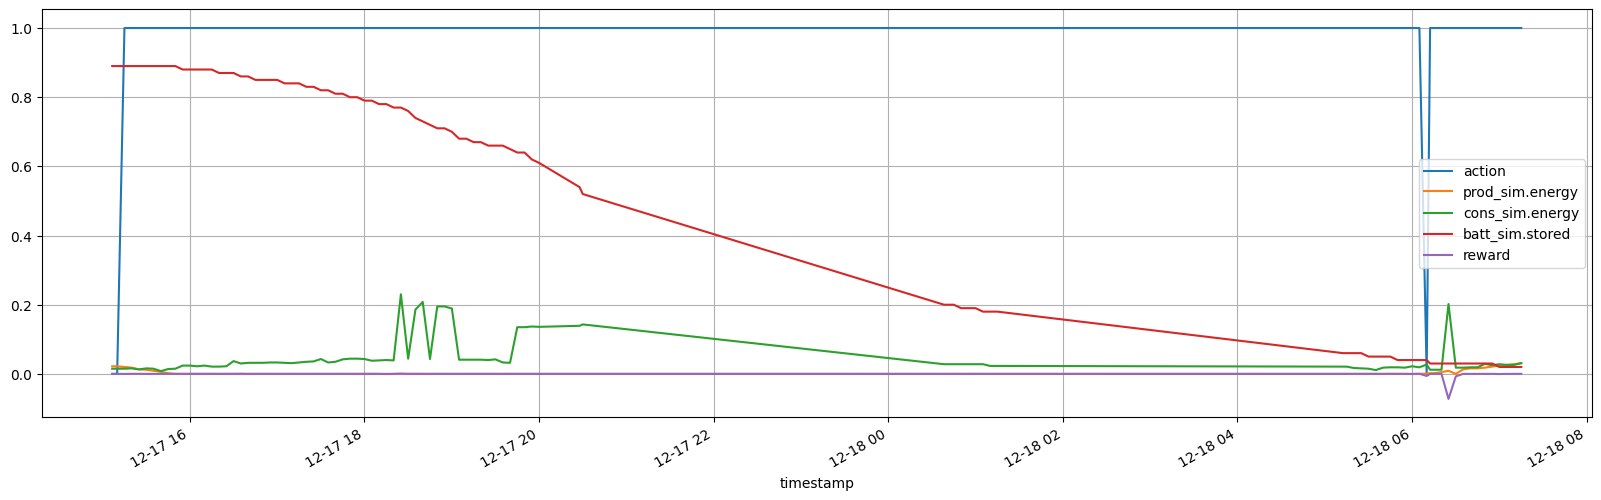

In [26]:
df_plot = sub_state_series_df[[
    'action',
    'prod_sim.energy',
    'cons_sim.energy',
    'batt_sim.stored',
    'reward',
]]
df_plot['action'] *= 1000
df_plot /= 1000
df_plot['batt_sim.stored'] /= 10
df_plot.plot(figsize=(20, 6), grid=True)